In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score,mean_absolute_error,median_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder

import warnings
warnings.filterwarnings('ignore')


In [2]:
df=pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\python\Machine learning\Machine_learning_practice\MLR_project\used bike price data set (1).csv')
df

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000
...,...,...,...,...,...,...,...,...,...
7307,Hero Hunk Rear Disc 150cc,25000,Delhi,48587,First Owner,8,150,Hero,120000
7308,Bajaj Avenger 220cc,35000,Bangalore,60000,First Owner,9,220,Bajaj,160000
7309,Harley-Davidson Street 750 ABS,450000,Jodhpur,3430,First Owner,4,750,Harley-Davidson,630000
7310,Bajaj Dominar 400 ABS,139000,Hyderabad,21300,First Owner,4,400,Bajaj,245000


In [3]:
df.head(5)

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000
2,Triumph Daytona 675R,600000,Delhi,110,First Owner,8,675,Triumph,1100000
3,TVS Apache RTR 180cc,65000,Bangalore,16329,First Owner,4,180,TVS,140000
4,Yamaha FZ S V 2.0 150cc-Ltd. Edition,80000,Bangalore,10000,First Owner,3,150,Yamaha,150000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7312 entries, 0 to 7311
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   bike_name       7312 non-null   object
 1   price           7312 non-null   int64 
 2   city            7312 non-null   object
 3   kms_driven      7312 non-null   int64 
 4   owner           7312 non-null   object
 5   age             7312 non-null   int64 
 6   power           7312 non-null   int64 
 7   brand           7312 non-null   object
 8   Original Price  7312 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 514.3+ KB


In [5]:
df.describe()

,price,kms_driven,age,power,Original Price
count,7.312000e+03,7312.000000,7312.000000,7312.000000,7.312000e+03
mean,8.495145e+04,23949.871718,6.733862,228.496991,1.823393e+05
std,1.207519e+05,27340.904392,3.857574,158.035118,1.835454e+05
min,4.400000e+03,1.000000,1.000000,100.000000,5.000000e+04
25%,3.000000e+04,10148.500000,4.000000,125.000000,9.000000e+04
50%,5.500000e+04,19000.000000,6.000000,160.000000,1.500000e+05
75%,1.000000e+05,30396.750000,8.000000,350.000000,2.150000e+05
max,1.900000e+06,750000.000000,63.000000,1800.000000,2.750000e+06


In [6]:
df.isnull().sum()

bike_name         0
price             0
city              0
kms_driven        0
owner             0
age               0
power             0
brand             0
Original Price    0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7307    False
7308    False
7309    False
7310    False
7311    False
Length: 7312, dtype: bool

In [8]:
# 3.2 Fix data types and handle missing values

df['price']=pd.to_numeric(df['price'].astype(str).str.replace(',',''),errors='coerce')
df['kms_driven']=pd.to_numeric(df['kms_driven'].astype(str).str.replace(',',''),errors='coerce')
df['age']=pd.to_numeric(df['age'],errors='coerce')
df['power']=pd.to_numeric(df['power'],errors='coerce')
df['Original Price']=pd.to_numeric(df['Original Price'].astype(str).str.replace(',',''),errors='coerce')

In [9]:
df.isnull().sum()

bike_name         0
price             0
city              0
kms_driven        0
owner             0
age               0
power             0
brand             0
Original Price    0
dtype: int64

In [11]:
# Drop row where target price is missing
df=df.dropna(subset=['price'])
df['owner']=df['owner'].fillna('First_Owner')
df=df.fillna(df.median(numeric_only=True))

In [12]:
# Remove outlier using IQR method 
def remove_outliers_iqr(data,col):
    Q1=data[col].quantile(0.25)
    Q3=data[col].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    return data[(data[col]>=lower)&(data[col]<=upper)]
num_cols =['kms_driven','age','power','Original Price']
for col in num_cols:
    df=remove_outliers_iqr(df,col)
print("\nshape after outlier removel:",df.shape)


shape after outlier removel: (6550, 9)


In [48]:
# Feature engineering
df['depreciation']=df['Original Price']-df['price']
df['depreciation_rate']=df['depreciation']/df['Original Price']
df['kms_per_year']=df['kms_driven']/(df['age']+1)


In [13]:
# categorical encoading
le_owner=LabelEncoder()
df['owner_encoded']=le_owner.fit_transform(df['owner'])

le_brand=LabelEncoder()
df['brand_encoded']=le_brand.fit_transform(df['brand'])

le_city=LabelEncoder()
df['city_encoded']=le_city.fit_transform(df['city'])
print(df.describe())

print(df.describe())

               price    kms_driven          age        power  Original Price  \
count    6550.000000   6550.000000  6550.000000  6550.000000     6550.000000   
mean    69658.347634  20708.161832     6.220611   211.494809   157869.465649   
std     48985.805843  13450.329871     2.742366   112.326086    70266.320805   
min      5800.000000      1.000000     1.000000   100.000000    50000.000000   
25%     32000.000000  10124.750000     4.000000   125.000000    90000.000000   
50%     55000.000000  18228.000000     6.000000   150.000000   150000.000000   
75%     96250.000000  28472.000000     8.000000   295.000000   215000.000000   
max    860000.000000  60500.000000    14.000000   650.000000   375000.000000   

       owner_encoded  brand_encoded  city_encoded  
count    6550.000000    6550.000000   6550.000000  
mean        0.176336       5.951908    159.980305  
std         0.589175       4.478275     94.921226  
min         0.000000       0.000000      0.000000  
25%         0.00000

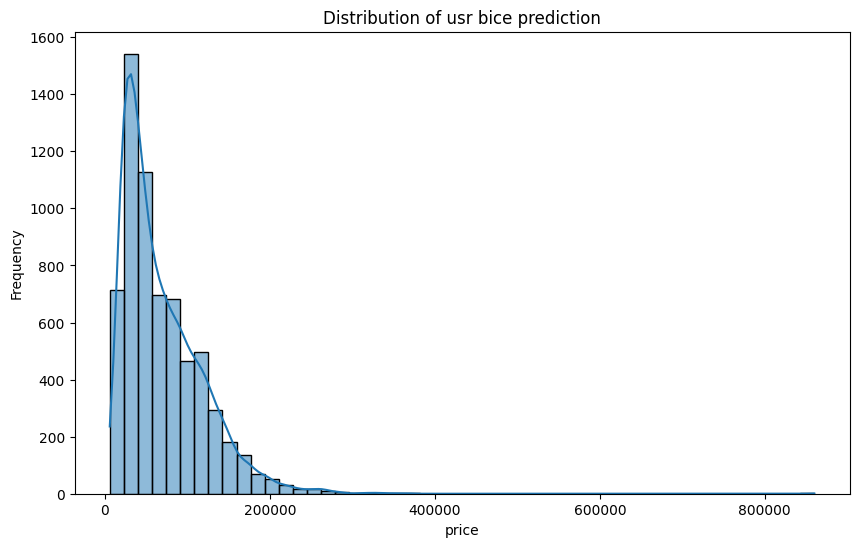

In [17]:
# Price Deatrbution
plt.figure(figsize=(10,6))
sns.histplot(df['price'],kde=True,bins=50)
plt.title("Distribution of usr bice prediction")
plt.xlabel('price')
plt.ylabel("Frequency")
plt.show()

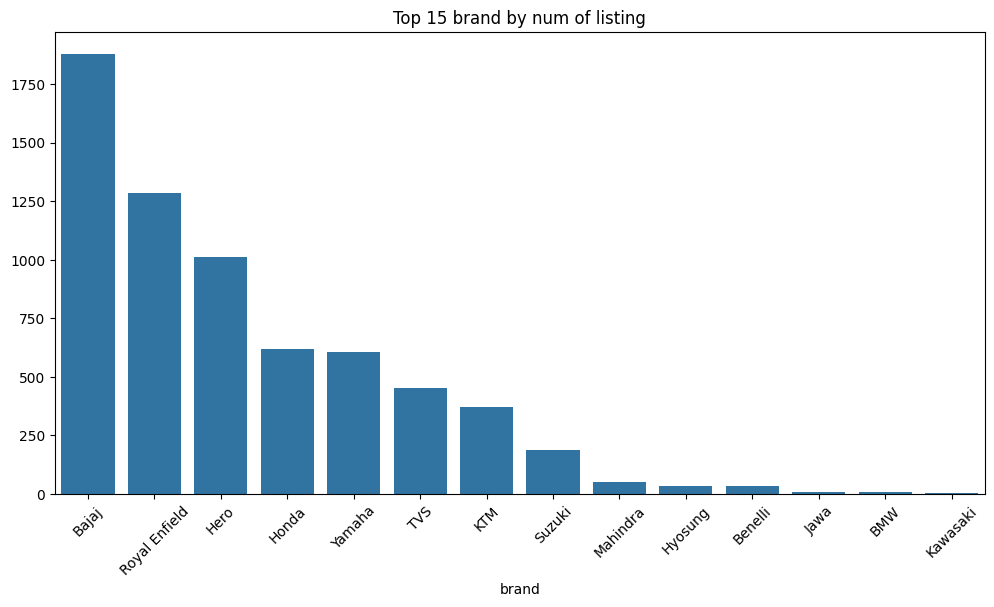

In [24]:
# top 15 brand by count
top_brand=df['brand'].value_counts().head(15)
plt.figure(figsize=(12,6))
sns.barplot(x=top_brand.index,y=top_brand.values)
plt.xticks(rotation=45)
plt.title("Top 15 brand by num of listing")
plt.show()

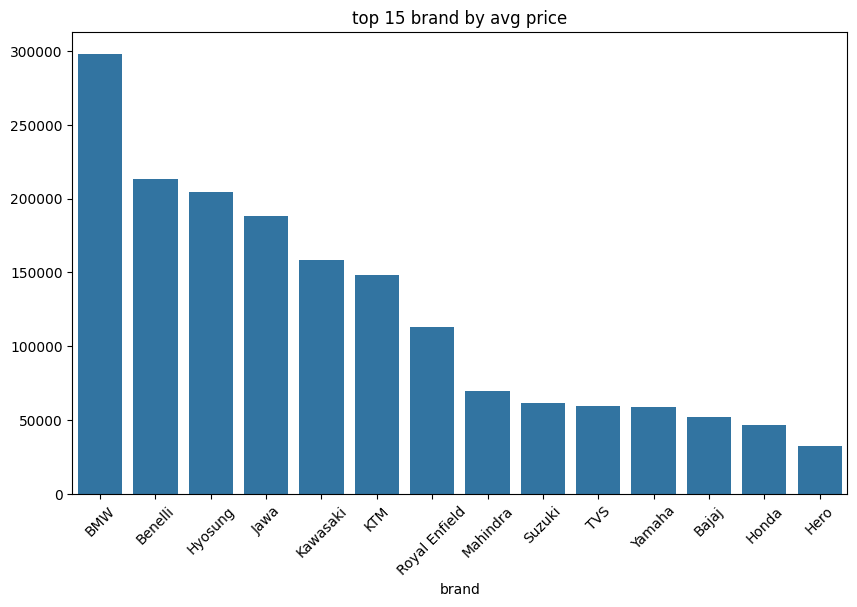

In [26]:
# top 15 brand by avg price
brand_price=df.groupby('brand')['price'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,6))
sns.barplot(x=brand_price.index,y=brand_price.values)
plt.xticks(rotation=45)
plt.title("top 15 brand by avg price")
plt.show()

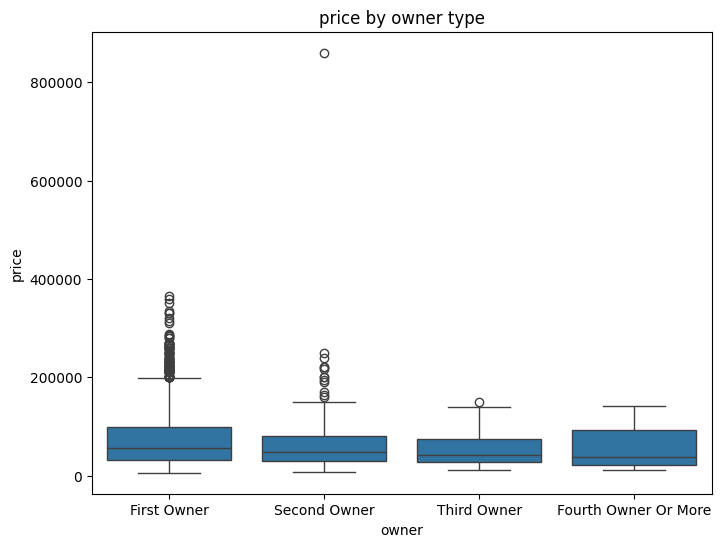

Highest Average Price Brands: Ducati, Harley-Davidson, Triumph, Indian, Kawasaki


In [ ]:
# Owner type vs price
plt.figure(figsize=(8,6))
sns.boxplot(x='owner',y='price',data=df)
plt.title("price by owner type")
plt.show()



Highest Average Price Brands: Ducati, Harley-Davidson, Triumph, Indian, Kawasaki


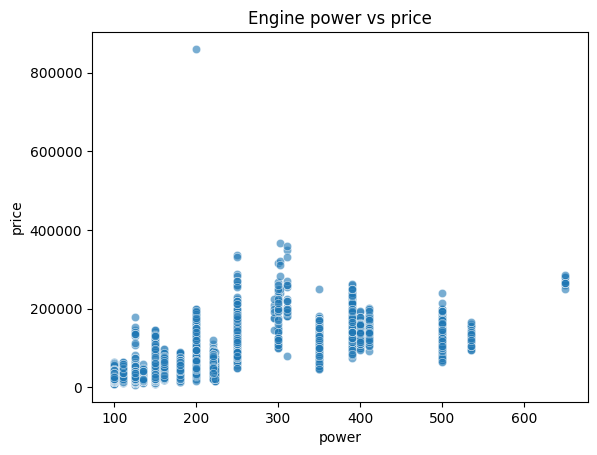

In [36]:
print('Highest Average Price Brands: Ducati, Harley-Davidson, Triumph, Indian, Kawasaki')
# power vs price
# plt.figure(figsize=(15,10))
sns.scatterplot(x='power',y='price',data=df,alpha=0.6)
plt.title("Engine power vs price")
plt.show()


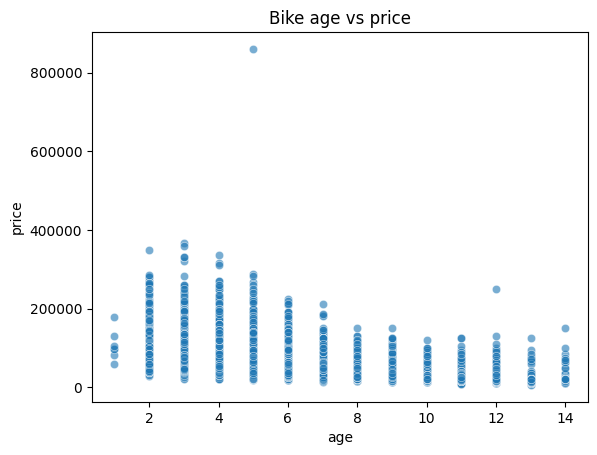

In [37]:
sns.scatterplot(data=df,x='age',y='price',alpha=0.6)
plt.title("Bike age vs price")
plt.show()

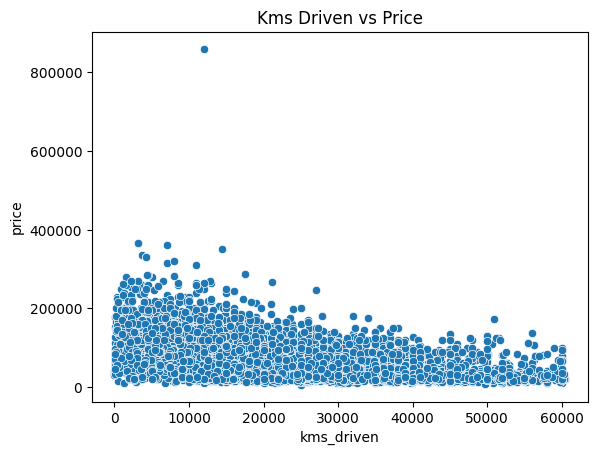

In [39]:
# Kms Driven vs Price
# plt.figure(figsize=(10,6))
sns.scatterplot(x='kms_driven', y='price', data=df)
plt.title('Kms Driven vs Price')
plt.show()

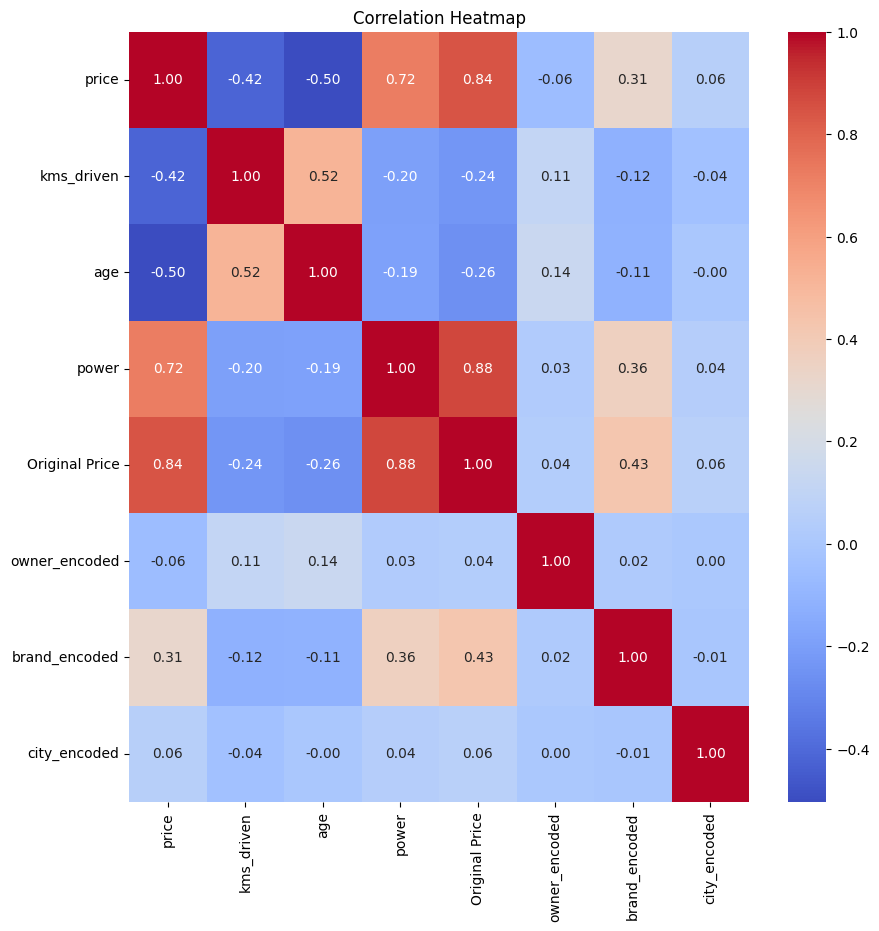

In [40]:
plt.figure(figsize=(10,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [52]:
# Top 10 most expensive used bike 
print("\nTop 10 Most Expensive Used Bikes:")
print(df[['bike_name','price','brand','power','age']].sort_values('price',ascending=False).head(10))


Top 10 Most Expensive Used Bikes:
               bike_name   price    brand  power  age
6425      KTM Duke 200cc  860000      KTM    200    5
285   Benelli 302R 300CC  366000  Benelli    302    3
2401         BMW G 310 R  360000      BMW    310    3
2069        BMW G 310 GS  350000      BMW    310    2
1812      Hyosung GT250R  335000  Hyosung    250    4
3222      Hyosung GT250R  330000  Hyosung    250    3
6722        BMW G 310 GS  330000      BMW    310    3
2637  Benelli 302R 300CC  320000  Benelli    302    3
1542     Benelli TNT 300  315000  Benelli    300    4
2766        Benelli 302R  310000  Benelli    302    4


In [53]:
df.head(2)

,bike_name,price,city,kms_driven,owner,age,power,brand,Original Price,owner_encoded,brand_encoded,city_encoded,depreciation,depreciation_rate,kms_per_year
0,TVS Star City Plus Dual Tone 110cc,35000,Ahmedabad,17654,First Owner,3,110,TVS,82500,0,12,6,47500,0.575758,4413.5
1,Royal Enfield Classic 350cc,119900,Delhi,11000,First Owner,4,350,Royal Enfield,230000,0,10,106,110100,0.478696,2200.0


In [ ]:
import statsmodels.api as sm

In [49]:
features = ['kms_driven', 'age', 'power', 'Original Price', 'depreciation_rate',
            'kms_per_year', 'owner_encoded', 'brand_encoded', 'city_encoded']

In [59]:
x=df[features]
y=df['price']
x=x.fillna(x.median())
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

x_train_sm=sm.add_constant(x_train)
model_sm=sm.OLS(y_train,x_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                 1.271e+04
Date:                Mon, 13 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:50:59   Log-Likelihood:                -55875.
No. Observations:                5240   AIC:                         1.118e+05
Df Residuals:                    5230   BIC:                         1.118e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const              9.812e+04    979.35

In [60]:
from sklearn.metrics import mean_squared_error


In [66]:
# prediction and evaluation
x_test_sm=sm.add_constant(x_test)
y_pred_sm=model_sm.predict(x_test_sm)
print("\nStastmodels Evaluation :")
print("R-squared",r2_score(y_test,y_pred_sm))
adj_r2=1-(1-r2_score(y_test,y_pred_sm))*(len(y_test)-1)/(len(y_test)-x_test.shape[1]-1)
print("Adjusted R-square:",adj_r2)
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred_sm)))
print("MAE:",mean_absolute_error(y_test,y_pred_sm))

lr=LinearRegression()
lr.fit(x_train_scaled,y_train)
y_pred_lr=lr.predict(x_test_scaled)


print("\n--- Scikit-learn Linear Regression Evaluation ---")
print('R-squared:',r2_score(y_test,y_pred_lr))
adj_r2_lr=1-(1-r2_score(y_test,y_pred_lr))
print("Adjusted R -quared:",adj_r2_lr)
print("RMSE :",np.sqrt(mean_squared_error(y_test,y_pred_lr)))
print("MAE :",mean_absolute_error(y_test,y_pred_lr))

# feature impoetance cofficient
coff_df=pd.DataFrame(lr.coef_,features,columns=['cofficient'])
print("\nTop POsitive Feature")
print(coff_df.sort_values('cofficient',ascending=False))





Stastmodels Evaluation :
R-squared 0.957219207626274
Adjusted R-square: 0.9569230329098405
RMSE : 9710.18145896967
MAE: 7080.9053733015335

--- Scikit-learn Linear Regression Evaluation ---
R-squared: 0.9572192076262741
Adjusted R -quared: 0.9572192076262741
RMSE : 9710.181458969655
MAE : 7080.905373301984

Top POsitive Feature
                     cofficient
Original Price     35822.039992
age                 3632.169072
kms_driven          1863.710389
owner_encoded       -466.729863
city_encoded        -518.142414
brand_encoded      -1320.647195
kms_per_year       -1386.490684
power              -3081.879677
depreciation_rate -29097.115927
